# در این مثال داده های 6 ساله تعمیرات اصلاحی و پیشگیرانه مربوط به یک مجموعه فن از یک پالایشگاه برای بهینه سازی تعمیرات پیشگیرانه براساس مدل سود و هزینه مورد بررسی قرار می گیرد.
## دیتاست را دانلود و در پوشه کاری قرار دهید.
fans.csv

### فراخوانی کتابخانه های مورد نیاز 

! pip install jdatetime datetime

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
from datetime import datetime, timedelta
import jdatetime
from jdatetime import date as jdate
from datetime import date

### توابع لازم برای پیش پردازش

In [2]:
# محاسبه هزینه براساس code
def calculate_cost(code):
    
    if pd.isna(code):
        return 0
    
    cost = 3  # هزینه سه کارگر
    
    code = code.upper()
    
    if 'A' in code: # روتین بررسی پره و تسمه
        cost += 1
        
    if 'B' in code: # روتین بررسی پره و تسمه و گریسکاری
        cost += 2
        
    if 'C' in code: # تعویض تسمه
        cost += 1.5
        
    if 'E' in code: # نصب داربست
        cost += 3
        
    if 'F' in code: # تعویض بیرینگ و آسیب جدی
        cost += 15
        
    if 'G' in code: # تعمیر الکتروموتور
        cost += 4
        
    if 'H' in code: # تنظیم کشش تسمه
        cost += 0.5
        
    if 'M' in code: # تنظیم زاویه پره
        cost += 0.5
        
    if 'N' in code: # خرابی پولی و هم محوری
        cost += 2

    # تعویض پره فن
    blade_matches = re.findall(r'(\d+)\*?D', code)
    if not blade_matches:
        # اگر هیچ عددی نیافت، خود "D" را چک کن
        if 'D' in code and not re.search(r'\d+', code):
            blade_matches = ['1']  # یعنی یک پره

    for m in blade_matches:
        blades = int(m) if m != '' else 1
        cost += blades * 1.5

    return cost

# پردازش تاریخ
def shamsi_to_gregorian(date_str):
        """تبدیل تاریخ شمسی به میلادی"""
        try:
            if pd.isna(date_str):
                return pd.NaT
                
            date_str = str(date_str).strip()
            date_str = ''.join(c for c in date_str if c.isdigit() or c in ['-', '/'])
            
            parts = date_str.replace('/', '-').split('-')
            if len(parts) == 3:
                year, month, day = parts
                year = int(year) if year.isdigit() else 1402
                month = int(month) if month.isdigit() else 1
                day = int(day) if day.isdigit() else 1
                
                year = max(1300, min(year, 1500))
                month = max(1, min(month, 12))
                day = max(1, min(day, 31))
                
                return jdatetime.date(year, month, day).togregorian()
                
        except Exception as e:
            print(f" خطا در تبدیل تاریخ {date_str}: {e}")
            
        return pd.NaT

### فراخوانی داده و پیش پردازش

In [3]:
df = pd.read_csv('fans.csv')
df['Date'] = df['Wo Start Date'].apply(shamsi_to_gregorian)
df = df.sort_values(by='Date', ascending=True)
df['Cost'] = df['Code'].apply(calculate_cost)
df.head()

,Equipment,Wo Start Date,Wo Type Code,Code,Date,Cost
418,E-8105A,1398/1/25,PM,B,2019-04-14,5.0
431,E-8107B,1398/1/25,PM,B,2019-04-14,5.0
430,E-8107A,1398/1/25,PM,B,2019-04-14,5.0
429,E-8106F,1398/1/25,PM,B,2019-04-14,5.0
428,E-8106E,1398/1/25,PM,B,2019-04-14,5.0


### تعیین failure vs PM

In [4]:
failure_codes = ['C','D','F','M', 'G','N']

def is_failure(Code):
    return any(fc in Code.upper() for fc in failure_codes)
        
df["is_failure"] = df["Code"].apply(is_failure)


def is_pm(Code):
    Code = Code.upper()
    return (('A' in Code) or ('B' in Code)) and (not is_failure(Code))
    
df['is_pm'] = df['Code'].apply(is_pm)
df.head()

,Equipment,Wo Start Date,Wo Type Code,Code,Date,Cost,is_failure,is_pm
418,E-8105A,1398/1/25,PM,B,2019-04-14,5.0,False,True
431,E-8107B,1398/1/25,PM,B,2019-04-14,5.0,False,True
430,E-8107A,1398/1/25,PM,B,2019-04-14,5.0,False,True
429,E-8106F,1398/1/25,PM,B,2019-04-14,5.0,False,True
428,E-8106E,1398/1/25,PM,B,2019-04-14,5.0,False,True


### استخراج رویدادهای failure

In [5]:
df['Date'] = pd.to_datetime(df['Date'], errors='coerce')

failures = df[df["is_failure"] == True].copy()
failures = failures.sort_values(['Equipment',"Date"]).copy()

failures["tbf"] = failures.groupby('Equipment')["Date"].diff()
failures = failures.dropna(subset=["tbf"])

failures["tbf_days"] = failures["tbf"].dt.total_seconds() / 86400

failures.head()

,Equipment,Wo Start Date,Wo Type Code,Code,Date,Cost,is_failure,is_pm,tbf,tbf_days
379,E-8105A,1399/3/31,CM,G,2020-06-20,7.0,True,False,69 days,69.0
404,E-8105A,1399/11/14,PM,B+D,2021-02-02,6.5,True,False,227 days,227.0
272,E-8105A,1400/4/7,CM,C,2021-06-28,4.5,True,False,146 days,146.0
205,E-8105A,1401/5/13,CM,C,2022-08-04,4.5,True,False,402 days,402.0
216,E-8105A,1401/8/3,PM,A+C,2022-10-25,5.5,True,False,82 days,82.0


In [6]:
failures = failures.sort_values(['Equipment', 'Date'])
failures.to_csv('failure.csv')

### نرخ خرابی λ

In [7]:
mean_tbf = failures["tbf_days"].mean()
lam = 1 / mean_tbf
lam

0.005392689106044155

### متوسط هزینه PM و Failure

In [8]:
cost_pm = df[df["is_pm"]== True]["Cost"].mean()

cost_failure = failures["Cost"].mean()

print('PM cost:', cost_pm, ', Failure cost:', cost_pm)

PM cost: 4.6847133757961785 , Failure cost: 4.6847133757961785


### مدل بهینه سازی تعمیرات پیشگیرانه براساس Weibull

In [9]:
from scipy.stats import weibull_min

tbf = failures['tbf_days'].dropna().values
beta, loc, eta = weibull_min.fit(tbf, floc=0)

print('Weibull shape beta =', beta)
print('Weibull scale eta =', eta)

def expected_cost_weibull(T):
    expected_failure = (T/eta)**beta
    total_cost = cost_pm + cost_failure * expected_failure
    return total_cost / T

Weibull shape beta = 0.9045350139505877
Weibull scale eta = 177.39714410710866


### یافتن زمان بهینه

In [10]:
candidate_T = np.arange(10, 401, 5)  # از 10 تا ۴۰۰ روز

costs = [expected_cost_weibull(t) for t in candidate_T]

best_index = np.argmin(costs)
best_T = candidate_T[best_index]
best_cost = costs[best_index]

print("Best PM Interval (days):", best_T)
print("Minimum cost per day:", best_cost)
print("Mean TBF =", mean_tbf)

Best PM Interval (days): 400
Minimum cost per day: 0.040837758364101154
Mean TBF = 185.43624161073825


#### با توجه به مدل خرابی ها، زمان بهینه ماکزیمم زمان انتخاب شده لحاظ شده است.

### نمودارها

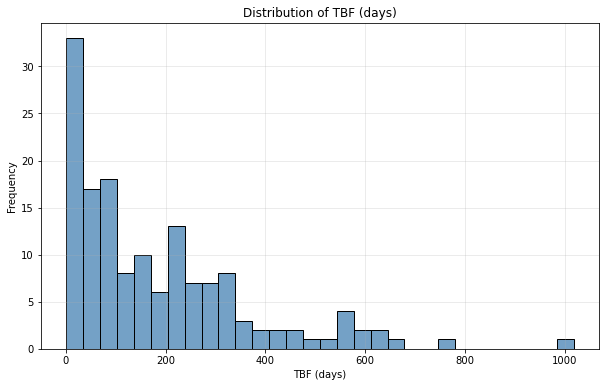

In [11]:
# 1) توزیع TBF
plt.figure(figsize=(10,6))
sns.histplot(failures["tbf_days"], bins=30, kde=False, color='steelblue')
plt.title("Distribution of TBF (days)")
plt.xlabel("TBF (days)")
plt.ylabel("Frequency")
plt.grid(True, alpha=0.3)
plt.show()

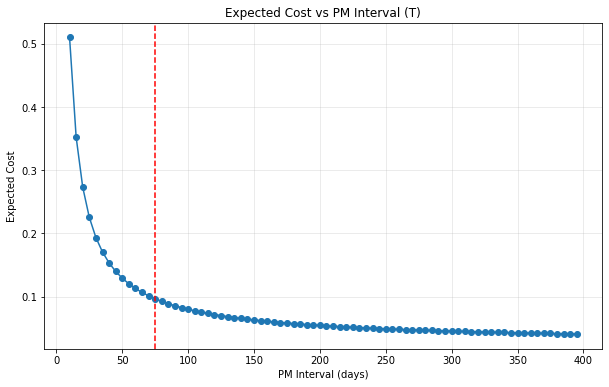

In [12]:
# 2) نمودار هزینه vs PM Interval
candidate_T = np.arange(10, 400, 5)
costs = [expected_cost_weibull(t) for t in candidate_T]

plt.figure(figsize=(10,6))
plt.plot(candidate_T, costs, marker='o')
plt.title("Expected Cost vs PM Interval (T)")
plt.xlabel("PM Interval (days)")
plt.ylabel("Expected Cost")
plt.grid(True, alpha=0.3)
# نمایش حداقل نقطه
slopes = np.gradient(costs, candidate_T)
epsilon = 0.001 #حد مجاز تغییر شیب
stable_points = candidate_T[np.where(np.abs(slopes) < epsilon)]
plt.axvline(min(stable_points), color='red', linestyle='--')

plt.show()

### دیتاست نشان دهنده مدل نرخ خرابی کاهشی است. از اینرو تعمیرات پیشگیرانه با زمان بندی سخت گیرانه احتمالا توجیه قوی ندارد. لذا براساس مدل ماکزیمم بازه به عنوان نقطه بهینه درنظر گرفته می شود. با این وجود در واقعیت می توان با محاسبه  شیب نمودار حداقل 75 روز را به عنوان بازه تعمیرات پیشگیرانه پیشنهاد نمود. 

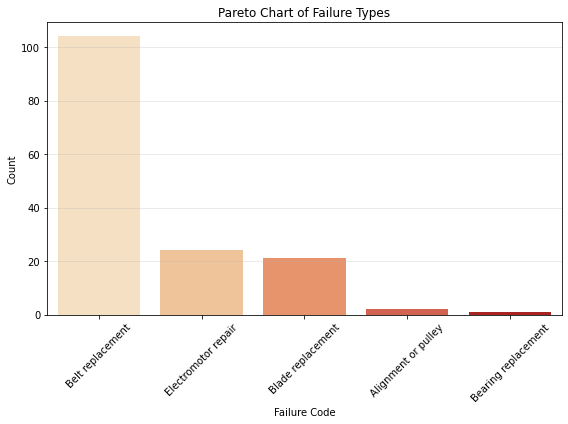

In [13]:
# 3) Pareto از failure codes
failure_map = {
    "C": "Belt replacement",
    "D": "Blade replacement",
    "F": "Bearing replacement",
    "G": "Electromotor repair",
    "N": "Alignment or pulley",
    "H": "adjustment Belt"
}
# شمارش خرابی ها بر اساس نوع failure
failure_counts = {}

for code in failures["Code"]:
    u = code.upper()
    for fc in failure_map.keys():
        if fc in u:
            label = failure_map[fc]
            failure_counts[label] = failure_counts.get(label, 0) + 1

failure_df = pd.DataFrame({
    "نوع خرابی": list(failure_counts.keys()),
    "تعداد": list(failure_counts.values())
}).sort_values("تعداد", ascending=False)

plt.figure(figsize=(8,6))
sns.barplot(data=failure_df, x="نوع خرابی", y="تعداد",  palette="OrRd")
plt.title("Pareto Chart of Failure Types")
plt.xlabel("Failure Code")
plt.xticks(rotation=45)
plt.ylabel("Count")
plt.grid(True, axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

##### عمده خرابی ها مربوط به تعویض تسمه می باشد درحالی این خرابی آسیبی به بخش های دیگر تجهیز نمیزند پس دارای اهمیت کمی است. 

### مقایسه حداقل و میانگین انواع خرابی ها

In [14]:
def split_codes(code):
    if pd.isna(code):
        return []
    return re.findall(r'[A-Z]', str(code).upper())

rows=[]
for _, row in df.iterrows():
    codes = split_codes(row['Code'])
    for c in codes:
        if c in failure_codes:
            rows.append({
                'Equipment':row['Equipment'], 
                'FailureCode': c,
                'Date': row['Date']
            })

fail = pd.DataFrame(rows)
fail = fail.drop_duplicates(subset=['Equipment', 'FailureCode', 'Date'])
fail = fail.sort_values(['Equipment', 'FailureCode', 'Date']).reset_index(drop=True)

fail['tbf_days'] = fail.groupby(['Equipment', 'FailureCode'])['Date'].diff().dt.days

means_tbf = (
    fail.groupby('FailureCode')['tbf_days']
    .mean()
    .reindex(['C','D','F','M', 'G','N'])
)
q1_tbf = (
    fail.groupby('FailureCode')['tbf_days']
    .quantile(0.25)
    .reindex(['C','D','F','M', 'G','N'])
)
count_tbf = (
    fail.groupby('FailureCode')['tbf_days']
    .count()
    .reindex(['C','D','F','M', 'G','N'])
)

result = pd.DataFrame({
    'Count': count_tbf,
    'Mean_TBF_Days': means_tbf,
    'Q1_TBF_Days': q1_tbf
})

print(result)

             Count  Mean_TBF_Days  Q1_TBF_Days
FailureCode                                   
C              100     259.710000         44.0
D               13     670.461538        356.0
F                0            NaN          NaN
M                0            NaN          NaN
G               14     533.357143        184.5
N                0            NaN          NaN


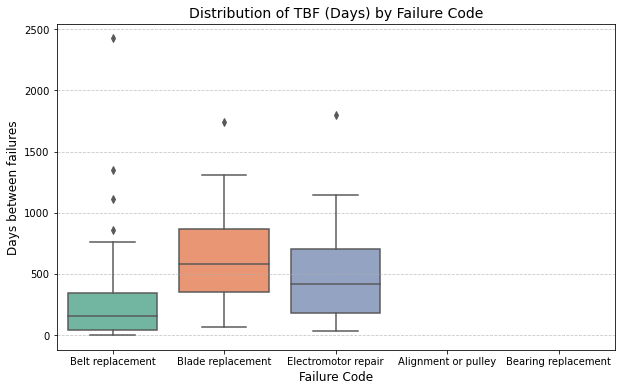

In [15]:
fail['FailureName'] = fail['FailureCode'].map(failure_map)

plt.figure(figsize=(10,6))
sns.boxplot(x='FailureName', y='tbf_days', data=fail, palette='Set2')
plt.title('Distribution of TBF (Days) by Failure Code', fontsize=14)
plt.xlabel('Failure Code', fontsize=12)
plt.ylabel('Days between failures', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

#### با توجه به نتایج، حداقل چارک برای تعویض تسمه 44 روز، پره 356 روز و خرابی موتور 184 روز محاسبه شده است. 